# NAME: M WARID ALI

# OIBSIP INTERNSHIP TASK NO 3

**Email spam Detection with Machine Learning**

Saving spam.csv to spam.csv
Shape: (5572, 2)

Missing values: 0

Class distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



After cleaning:


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


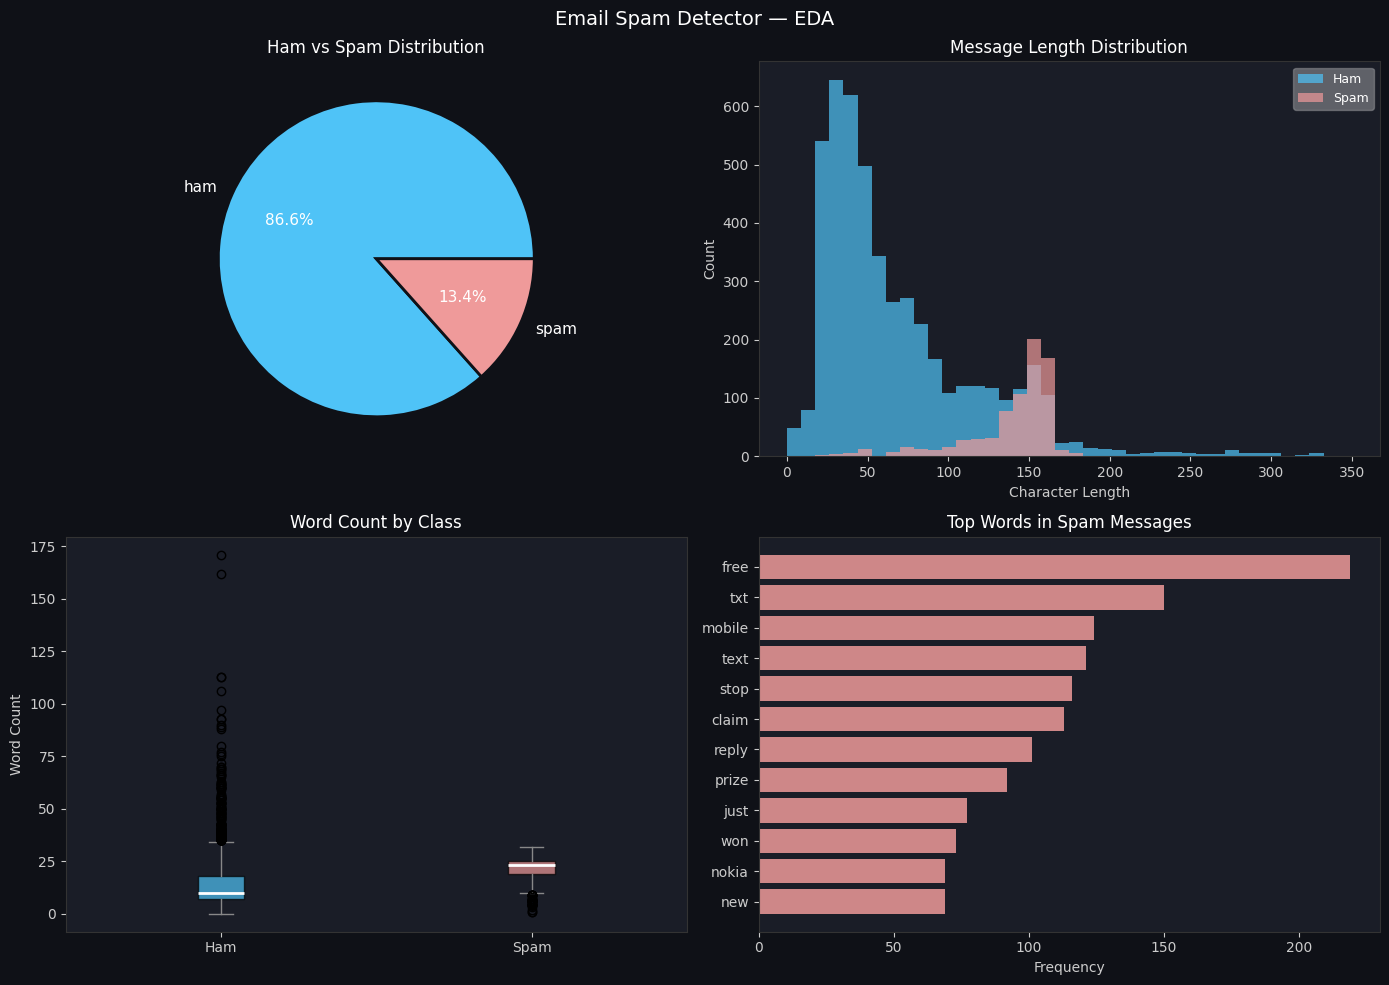


Train size: (4457, 3000) | Test size: (1115, 3000)

Model                    Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Naive Bayes                0.9704     0.9915     0.7852     0.8764
Logistic Regression        0.9641     0.9910     0.7383     0.8462
SVM                        0.9839     0.9852     0.8926     0.9366
Random Forest              0.9740     0.9839     0.8188     0.8938

 Best Model: SVM (F1 = 0.9366)


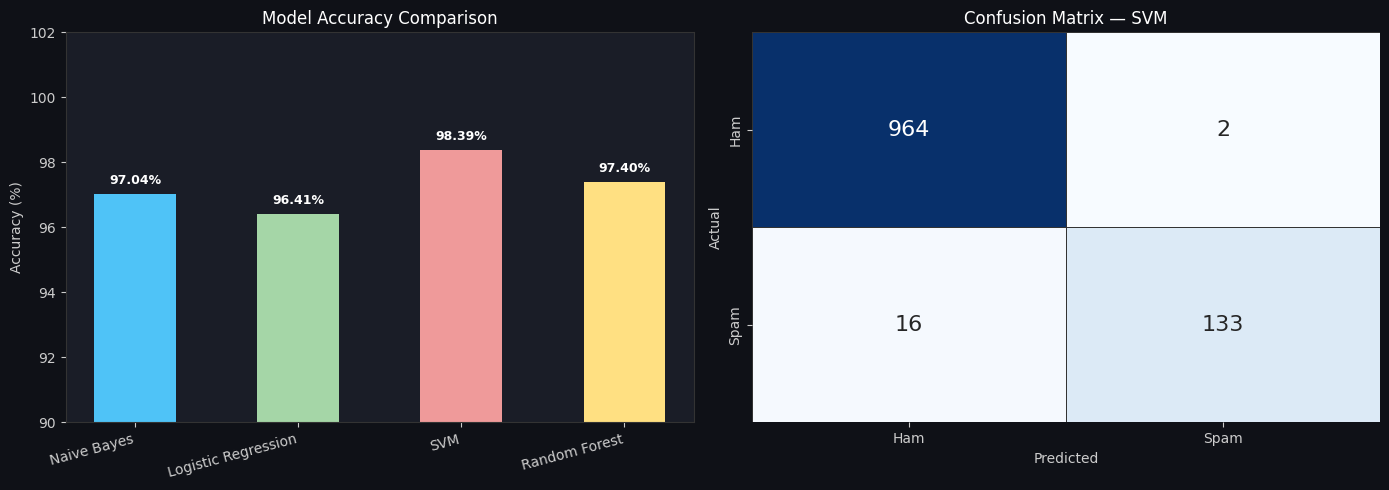


Classification Report — SVM:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Testing on custom messages:
  [SPAM] Congratulations! You've won a free iPhone. Click here to claim now!!!
  [HAM] Hey, are we still on for lunch tomorrow?
  [SPAM] URGENT: Your account will be suspended. Verify your details immediately.
  [HAM] Can you send me the report by end of day?


In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('spam.csv', encoding='latin-1')


df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:\n", df['label'].value_counts())
print("\nFirst 5 rows:")
display(df.head())

#  2. TEXT CLEANING
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()               # remove extra whitespace
    return text

df['clean_message'] = df['message'].apply(clean_text)
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['clean_message'].apply(lambda x: len(x.split()))

print("\nAfter cleaning:")
display(df[['label', 'message', 'clean_message']].head())

# 3. EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

# Plot 1 — Class Distribution
counts = df['label'].value_counts()
colors_pie = ['#4fc3f7', '#ef9a9a']
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors_pie, textprops={'color': 'white', 'fontsize': 11},
            wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
axes[0].set_title('Ham vs Spam Distribution', color='white', fontsize=12)

# Plot 2 — Message Length Distribution
ham_len = df[df['label'] == 'ham']['message_length'].values
spam_len = df[df['label'] == 'spam']['message_length'].values
axes[1].hist(ham_len, bins=40, alpha=0.7, color='#4fc3f7', label='Ham', range=(0, 350))
axes[1].hist(spam_len, bins=40, alpha=0.7, color='#ef9a9a', label='Spam', range=(0, 350))
axes[1].set_title('Message Length Distribution', color='white', fontsize=12)
axes[1].set_xlabel('Character Length', color='#ccc')
axes[1].set_ylabel('Count', color='#ccc')
axes[1].legend(fontsize=9, framealpha=0.3, labelcolor='white')

# Plot 3 — Word Count Box Plot
word_groups = [df[df['label'] == l]['word_count'].values for l in ['ham', 'spam']]
bp = axes[2].boxplot(word_groups, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4fc3f7', '#ef9a9a']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#888')
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Ham', 'Spam'], color='#ccc')
axes[2].set_title('Word Count by Class', color='white', fontsize=12)
axes[2].set_ylabel('Word Count', color='#ccc')

# Plot 4 — Top Spam Words
spam_words = ' '.join(df[df['label'] == 'spam']['clean_message']).split()
spam_words = [w for w in spam_words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
top_spam = pd.Series(spam_words).value_counts().head(12).sort_values()
axes[3].barh(top_spam.index, top_spam.values, color='#ef9a9a', edgecolor='none', alpha=0.85)
axes[3].set_title('Top Words in Spam Messages', color='white', fontsize=12)
axes[3].set_xlabel('Frequency', color='#ccc')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#ccc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig.suptitle('Email Spam Detector — EDA', color='white', fontsize=14)
plt.tight_layout()
plt.show()

#  4. PREPROCESSING
le = LabelEncoder()
y = le.fit_transform(df['label'])   # ham=0, spam=1

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_message'], y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(f"\nTrain size: {X_train.shape} | Test size: {X_test.shape}")

#  5. TRAIN MODELS
models = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=300),
    'SVM':                 SVC(kernel='linear', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"\n{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}
    print(f"{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

best_name = max(results, key=lambda k: results[k]['f1'])
best = results[best_name]
print(f"\n Best Model: {best_name} (F1 = {best['f1']:.4f})")

#  6. RESULTS PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Accuracy comparison
names = list(results.keys())
accs = [results[n]['acc'] * 100 for n in names]
bars = axes[0].bar(names, accs, color=['#4fc3f7', '#a5d6a7', '#ef9a9a', '#ffe082'],
                   width=0.5, edgecolor='none')
axes[0].set_ylim(90, 102)
axes[0].set_title('Model Accuracy Comparison', color='white', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', color='#ccc')
axes[0].set_xticklabels(names, rotation=15, ha='right', color='#ccc')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', color='white', fontsize=9, fontweight='bold')

# Confusion matrix for best model
cm = confusion_matrix(y_test, best['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            ax=axes[1], cbar=False, annot_kws={'size': 16},
            linewidths=0.5, linecolor='#333')
axes[1].set_title(f'Confusion Matrix — {best_name}', color='white', fontsize=12)
axes[1].set_xlabel('Predicted', color='#ccc')
axes[1].set_ylabel('Actual', color='#ccc')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#ccc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

plt.tight_layout()
plt.show()

#  7. CLASSIFICATION REPORT
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, best['preds'], target_names=['Ham', 'Spam']))

# 8. TEST ON CUSTOM MESSAGES
def predict_spam(message, model=best['model'], vectorizer=tfidf):
    cleaned = clean_text(message)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return 'SPAM' if pred == 1 else 'HAM'

test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!!!",
    "Hey, are we still on for lunch tomorrow?",
    "URGENT: Your account will be suspended. Verify your details immediately.",
    "Can you send me the report by end of day?",
]

print("\nTesting on custom messages:")
for msg in test_messages:
    print(f"  [{predict_spam(msg)}] {msg}")
